In [1]:
import sys; print(sys.executable)

/Users/znredra/Desktop/clinical-trial-termination/venv/bin/python3.13


In [2]:
import pandas as pd

df = pd.read_parquet("../data/processed/trials.parquet")
print(df.shape)
df.head

(15461, 25)


<bound method NDFrame.head of             nct_id     status      study_type         phase  enroll_count  \
0      NCT04587986  COMPLETED  INTERVENTIONAL            NA          67.0   
1      NCT05085886  COMPLETED  INTERVENTIONAL            NA         605.0   
2      NCT01939886  COMPLETED  INTERVENTIONAL        PHASE3         219.0   
3      NCT02868086  COMPLETED  INTERVENTIONAL            NA          68.0   
4      NCT04782986  COMPLETED  INTERVENTIONAL            NA         100.0   
...            ...        ...             ...           ...           ...   
15456  NCT01856140  COMPLETED  INTERVENTIONAL  EARLY_PHASE1          12.0   
15457  NCT04541940  COMPLETED  INTERVENTIONAL            NA          16.0   
15458  NCT01672840  COMPLETED  INTERVENTIONAL            NA         120.0   
15459  NCT01354340  COMPLETED  INTERVENTIONAL            NA          45.0   
15460  NCT02062840  COMPLETED  INTERVENTIONAL            NA          23.0   

      enroll_type start_date_string sponsor_c

In [3]:
print(df.columns.tolist())

['nct_id', 'status', 'study_type', 'phase', 'enroll_count', 'enroll_type', 'start_date_string', 'sponsor_class', 'collaborator_count', 'conditions', 'sites_count', 'countries_count', 'min_age_raw', 'max_age_raw', 'sex', 'healthy_volunteers', 'eligibility_criteria', 'intervention_types', 'allocation', 'masking', 'start_date', 'terminated', 'min_age', 'max_age', 'snapshot']


In [4]:
df["terminated"].value_counts(normalize=True)

terminated
0    0.888817
1    0.111183
Name: proportion, dtype: float64

In [5]:
df.groupby("phase")["terminated"].agg(["mean", "count"])

,mean,count
phase,,
EARLY_PHASE1,0.112108,223
NA,0.073622,8272
PHASE1,0.131214,2454
PHASE2,0.204052,2073
PHASE3,0.147263,1297
PHASE4,0.127886,1126


In [6]:
df.groupby("sponsor_class")["terminated"].agg(["mean", "count"])

,mean,count
sponsor_class,,
FED,0.118056,144
INDIV,0.000000,17
INDUSTRY,0.135651,4401
NETWORK,0.113924,79
NIH,0.190840,131
OTHER,0.102005,10372
OTHER_GOV,0.041009,317


In [7]:
df["enroll_decile"] = pd.qcut(df["enroll_count"], 10)
df.groupby("enroll_decile")["terminated"].mean()

enroll_decile
(-0.001, 12.0]        0.381375
(12.0, 20.0]          0.135605
(20.0, 30.0]          0.097808
(30.0, 40.0]          0.083333
(40.0, 53.0]          0.076308
(53.0, 72.0]          0.057069
(72.0, 102.0]         0.064010
(102.0, 163.0]        0.056106
(163.0, 335.0]        0.057717
(335.0, 3827656.0]    0.053109
Name: terminated, dtype: float64

In [8]:
df.groupby("terminated")["enroll_count"].median()

terminated
0    60.0
1    19.0
Name: enroll_count, dtype: float64

In [9]:
df.groupby("enroll_type")["terminated"].mean()
df.groupby(["enroll_type", "terminated"])["enroll_count"].median()

enroll_type  terminated
ACTUAL       0             60.0
             1             19.0
ESTIMATED    0             60.0
             1             80.0
Name: enroll_count, dtype: float64

In [10]:
df["enroll_count"].value_counts().head(20)

enroll_count
30.0     472
60.0     435
20.0     415
40.0     392
10.0     290
24.0     284
50.0     284
12.0     260
100.0    226
16.0     200
15.0     198
80.0     189
36.0     172
18.0     172
32.0     168
6.0      164
22.0     164
120.0    160
25.0     149
21.0     149
Name: count, dtype: int64

In [11]:
df.groupby(df["start_date"].dt.year)["terminated"].mean()

start_date
2010    0.132905
2011    0.114169
2012    0.106383
2013    0.115350
2014    0.106985
2015    0.100324
2016    0.098526
2017    0.116815
2018    0.111198
2019    0.121401
2020    0.132933
2021    0.104956
2022    0.090838
Name: terminated, dtype: float64

In [12]:
import os
import matplotlib.pyplot as plt
os.makedirs("figures", exist_ok=True)   # creates notebooks/figures/ if it's not there

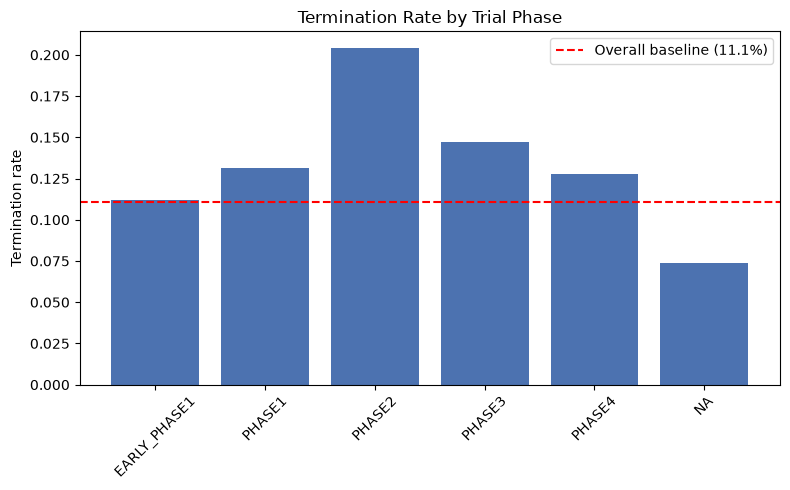

In [13]:
# order phases logically rather than alphabetically
phase_order = ["EARLY_PHASE1", "PHASE1", "PHASE2", "PHASE3", "PHASE4", "NA"]
rates = df.groupby("phase")["terminated"].mean().reindex(phase_order)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(rates.index, rates.values, color="#4C72B0")
ax.axhline(0.111, color="red", linestyle="--", label="Overall baseline (11.1%)")
ax.set_ylabel("Termination rate")
ax.set_title("Termination Rate by Trial Phase")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/termination_by_phase.png", dpi=150)
plt.show()

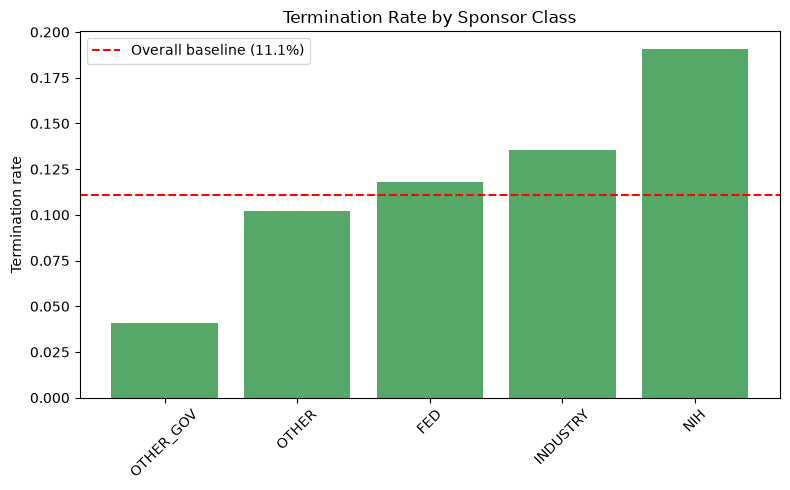

In [14]:
# sort by rate, keep only the well-sampled groups for a cleaner chart
counts = df["sponsor_class"].value_counts()
big = counts[counts >= 100].index          # drop tiny/noisy groups
rates = df[df["sponsor_class"].isin(big)].groupby("sponsor_class")["terminated"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(rates.index, rates.values, color="#55A868")
ax.axhline(0.111, color="red", linestyle="--", label="Overall baseline (11.1%)")
ax.set_ylabel("Termination rate")
ax.set_title("Termination Rate by Sponsor Class")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/termination_by_sponsor.png", dpi=150)
plt.show()

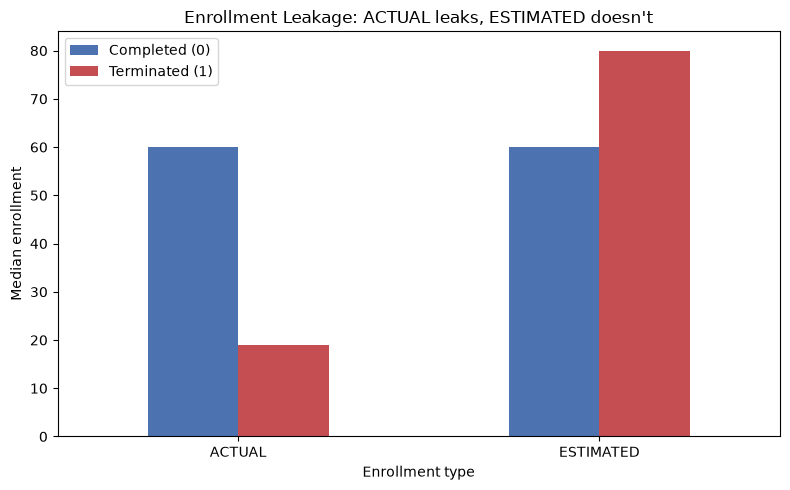

In [15]:
# median enrollment: terminated vs completed, split by enroll_type
med = df.groupby(["enroll_type", "terminated"])["enroll_count"].median().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
med.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Median enrollment")
ax.set_xlabel("Enrollment type")
ax.set_title("Enrollment Leakage: ACTUAL leaks, ESTIMATED doesn't")
ax.legend(["Completed (0)", "Terminated (1)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/enrollment_leakage.png", dpi=150)
plt.show()